<a href="https://colab.research.google.com/github/DarshanaDDevi/waste_management_ML_model/blob/main/Untitled10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score


In [2]:
df = pd.read_excel('/content/Small_Waste_Segregation_Dataset.xlsx')
df.head()


,WasteID,WasteType,Material,Biodegradable,Recyclable,Hazardous,ImageLink
0,W001,Organic,Food Waste,Yes,No,No,https://www.google.com/search?q=food+waste&tbm...
1,W002,Recyclable,Plastic,No,Yes,No,https://www.google.com/search?q=plastic+waste&...
2,W003,Hazardous,Battery,No,No,Yes,https://www.google.com/search?q=battery+waste&...
3,W004,Organic,Garden Waste,Yes,No,No,https://www.google.com/search?q=garden+waste&t...
4,W005,Recyclable,Paper,Yes,Yes,No,https://www.google.com/search?q=paper+waste&tb...


In [3]:
le = LabelEncoder()

df['Material'] = le.fit_transform(df['Material'])          # e.g., Plastic → 4
df['WasteType'] = le.fit_transform(df['WasteType'])        # e.g., Organic → 1
df['Biodegradable'] = df['Biodegradable'].map({'Yes': 1, 'No': 0})
df['Recyclable'] = df['Recyclable'].map({'Yes': 1, 'No': 0})
df['Hazardous'] = df['Hazardous'].map({'Yes': 1, 'No': 0})


In [4]:
X = df[['Material', 'Biodegradable', 'Recyclable', 'Hazardous']]
y = df['WasteType']


In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [6]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [7]:
y_pred = model.predict(X_test)

print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))



Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           2       0.50      1.00      0.67         1

    accuracy                           0.67         3
   macro avg       0.75      0.75      0.67         3
weighted avg       0.83      0.67      0.67         3

Accuracy: 0.6666666666666666


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns


/tmp/ipython-input-1222380973.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=waste_type_names, palette="Set2")


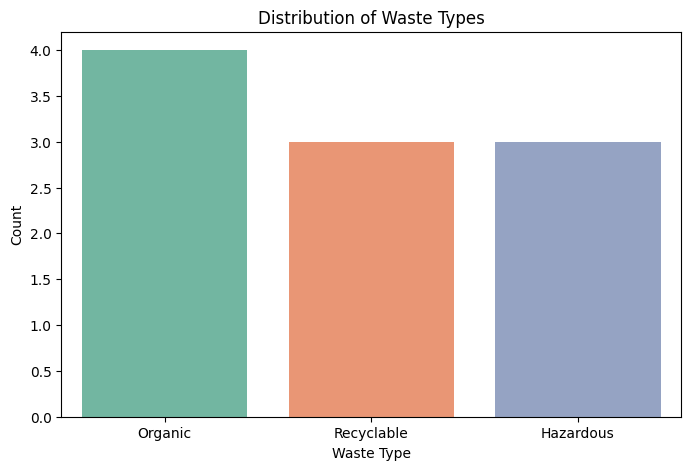

In [13]:
# Decode waste type labels
waste_type_names = le.inverse_transform(df['WasteType'])

plt.figure(figsize=(8, 5))
sns.countplot(x=waste_type_names, palette="Set2")
plt.title("Distribution of Waste Types")
plt.xlabel("Waste Type")
plt.ylabel("Count")
plt.show()


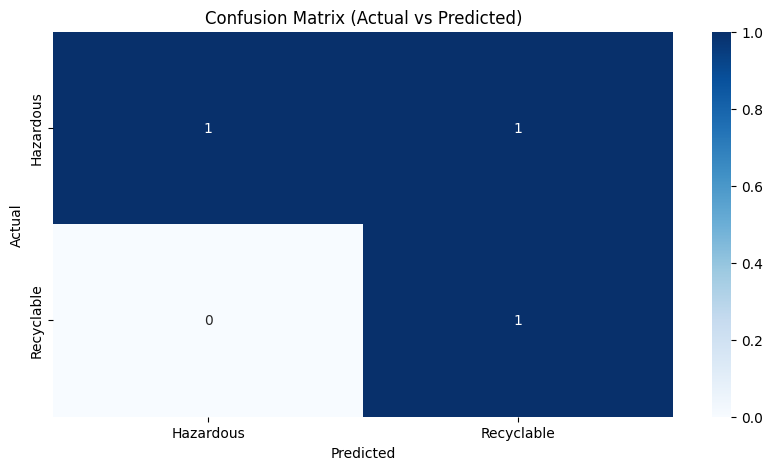

In [14]:
# Only run this after predictions
predicted_names = le.inverse_transform(y_pred)
true_names = le.inverse_transform(y_test)

# Plot comparison for small test set
plt.figure(figsize=(10, 5))
sns.heatmap(pd.crosstab(pd.Series(true_names, name='Actual'),
                        pd.Series(predicted_names, name='Predicted')),
            annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (Actual vs Predicted)")
plt.show()


/tmp/ipython-input-1531251950.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model.feature_importances_, y=X.columns, palette="viridis")


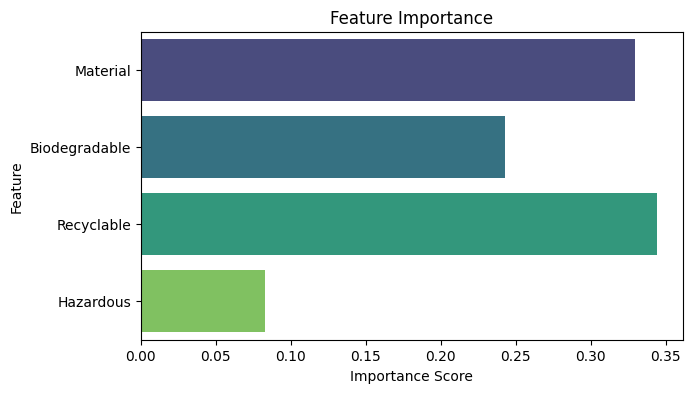

In [15]:
# Plot feature importances
plt.figure(figsize=(7, 4))
sns.barplot(x=model.feature_importances_, y=X.columns, palette="viridis")
plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()


In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# Keras model
keras_model = Sequential([
    Dense(32, input_dim=X.shape[1], activation='relu'),
    Dense(64, activation='relu'),
    Dense(3, activation='softmax')  # 3 classes: Organic, Recyclable, Hazardous
])

keras_model.compile(optimizer=Adam(learning_rate=0.01),
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy'])


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
history = keras_model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=20)


Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.2857 - loss: 1.1884 - val_accuracy: 0.6667 - val_loss: 1.0004
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - accuracy: 0.8571 - loss: 0.8135 - val_accuracy: 0.3333 - val_loss: 0.9910
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - accuracy: 0.7143 - loss: 0.6840 - val_accuracy: 0.3333 - val_loss: 1.0556
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 253ms/step - accuracy: 0.7143 - loss: 0.6022 - val_accuracy: 0.3333 - val_loss: 1.1320
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 0.8571 - loss: 0.5403 - val_accuracy: 0.3333 - val_loss: 1.1742
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.8571 - loss: 0.4903 - val_accuracy: 0.3333 - val_loss: 1.1764
Epoch 7/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.8571 - loss: 0.4351 - val_accuracy: 0.3333 - val_loss: 1.1765
Epoch 8/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 1.0000 - loss: 0.3851 - val_accuracy: 0.3333 - val_loss: 1.1

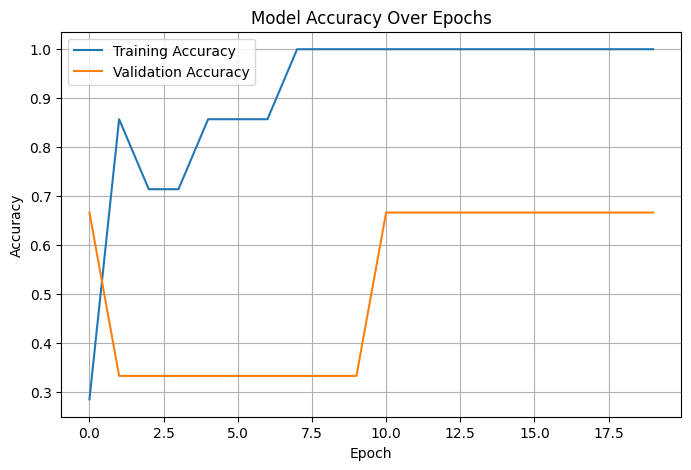

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()
